# Stroke Prediction using Classification Techniques
### Data Mining Mid-term Project — DSC306
**COMSATS University Islamabad**
## **Submitted By:**
## Maryam Muzammil (FA24-BDS-028)

## Muhammad Yahya Imran (FA24-BDS-002)


---
**Dataset:** Healthcare Stroke Dataset (Kaggle)  
**Models:** Decision Tree | Rule-Based Classifier (RIPPER) | SVM | Naive Bayes  
**Target Variable:** stroke (0 = No Stroke, 1 = Stroke)

**Structure:**
1. Importing Libraries
2. Loading the Dataset
3. Understanding the Data
4. Models — BEFORE Preprocessing (Baseline)
5. Data Preprocessing
6. Models — AFTER Preprocessing
7. Before vs After Comparison
8. Most Important Metric
9. Business Insights and Conclusion

---
## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wittgenstein

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import wittgenstein as lw   # Rule-Based Classifier (RIPPER algorithm)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.6/110.6 kB 3.6 MB/s eta 0:00:00
All libraries imported successfully.


---
## 2. Loading the Dataset

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


---
## 3. Understanding the Data

In [3]:
# General information about columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# Exploratory Data Analysis

In [4]:
# Statistical summary of numerical columns
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
# Check target variable distribution
print('Stroke value counts:')
print(df['stroke'].value_counts())
print()
print('Stroke percentage:')
print(df['stroke'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Stroke value counts:
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke percentage:
stroke
0    95.13%
1     4.87%
Name: proportion, dtype: object


### 3.1 Class Distribution Plot

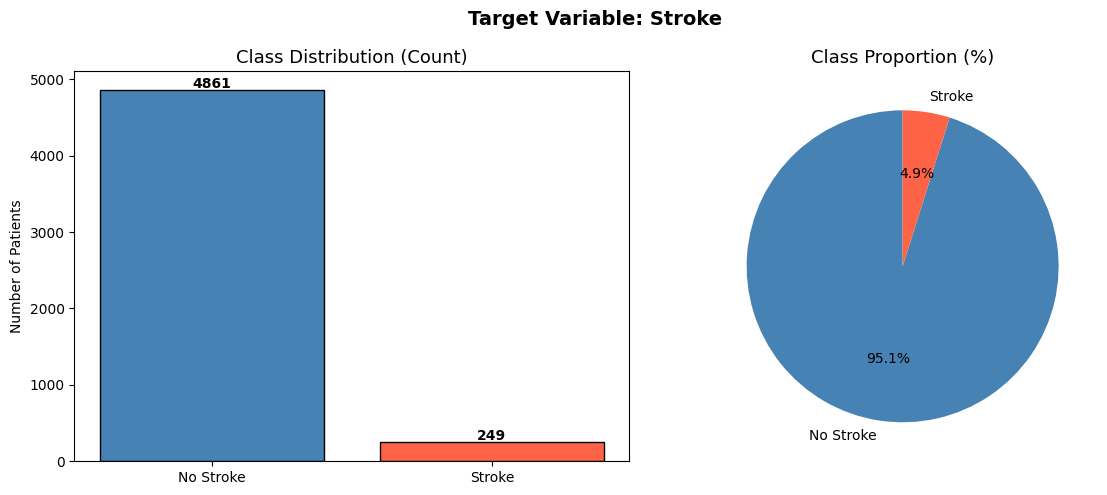

In [6]:
# Class distribution: bar chart + pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['stroke'].value_counts().sort_index()

axes[0].bar(['No Stroke', 'Stroke'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Proportion (%)', fontsize=13)

plt.suptitle('Target Variable: Stroke', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

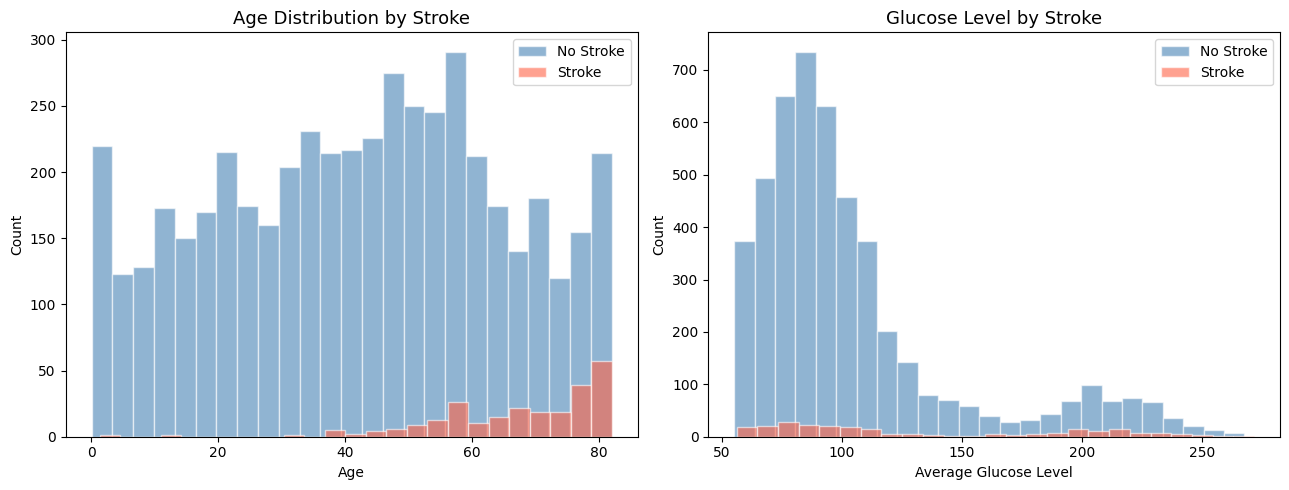

In [7]:
# Age and Glucose distribution split by stroke outcome
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for val, color, label in [(0, 'steelblue', 'No Stroke'), (1, 'tomato', 'Stroke')]:
    sub = df[df['stroke'] == val]
    axes[0].hist(sub['age'], bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[1].hist(sub['avg_glucose_level'], bins=25, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Age Distribution by Stroke', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].set_title('Glucose Level by Stroke', fontsize=13)
axes[1].set_xlabel('Average Glucose Level')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

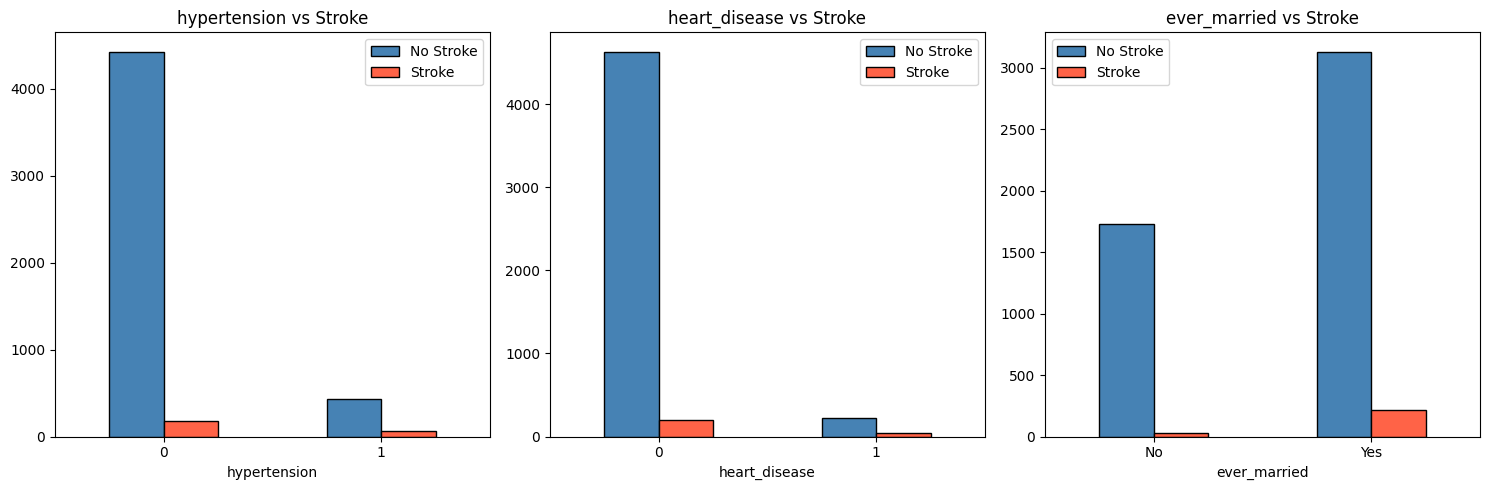

In [8]:
# Categorical features vs stroke
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['hypertension', 'heart_disease', 'ever_married']):
    ct = df.groupby([col, 'stroke']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black', rot=0)
    ax.set_title(col + ' vs Stroke', fontsize=12)
    ax.set_xlabel(col)
    ax.legend(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.show()

---
## 4. Models — BEFORE Preprocessing (Baseline)

Here we run all 4 models on the **raw data** — no binning, no scaling, no class balancing.
We only do the minimum steps needed to make the data readable for the models:
- Drop the id column
- Fill missing BMI values with the mean
- Remove the single 'Other' gender row
- Label encode text columns

This gives us a **baseline** to compare against later.

In [14]:
# ── Minimal preparation on raw data ──
df_raw = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Drop id (not useful for prediction)
df_raw = df_raw.drop(columns=['id'])

# Fill missing BMI
df_raw['bmi'] = pd.to_numeric(df_raw['bmi'], errors='coerce')
df_raw['bmi'] = df_raw['bmi'].fillna(df_raw['bmi'].mean())

# Remove 'Other' gender row
df_raw = df_raw[df_raw['gender'] != 'Other'].reset_index(drop=True)

# Label encode categorical columns
df_raw_enc = df_raw.copy()
le_raw = LabelEncoder()
for col in df_raw_enc.select_dtypes(include='object').columns:
    df_raw_enc[col] = le_raw.fit_transform(df_raw_enc[col])

# Train-test split
X_raw = df_raw_enc.drop('stroke', axis=1)
y_raw = df_raw_enc['stroke']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print('Raw data shape:', X_raw.shape)
print('Features:', list(X_raw.columns))
print('Train size:', X_train_raw.shape[0], '| Test size:', X_test_raw.shape[0])

Raw data shape: (5109, 10)
Features: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Train size: 4087 | Test size: 1022


### 4.1 Decision Tree — Before Preprocessing

=== Decision Tree — BEFORE Preprocessing ===
Accuracy : 0.9481
Precision: 0.2857
Recall   : 0.0400
F1 Score : 0.0702


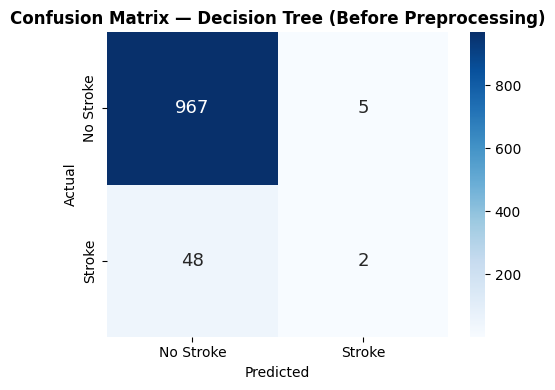

In [13]:
# Decision Tree on RAW data (no class_weight, no scaling)
dt_raw = DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                 min_samples_leaf=5, random_state=42)
dt_raw.fit(X_train_raw, y_train_raw)
y_pred_dt_raw = dt_raw.predict(X_test_raw)

acc_dt_raw  = accuracy_score(y_test_raw, y_pred_dt_raw)
prec_dt_raw = precision_score(y_test_raw, y_pred_dt_raw, zero_division=0)
rec_dt_raw  = recall_score(y_test_raw, y_pred_dt_raw)
f1_dt_raw   = f1_score(y_test_raw, y_pred_dt_raw, zero_division=0)

print('=== Decision Tree — BEFORE Preprocessing ===')
print(f'Accuracy : {acc_dt_raw:.4f}')
print(f'Precision: {prec_dt_raw:.4f}')
print(f'Recall   : {rec_dt_raw:.4f}')
print(f'F1 Score : {f1_dt_raw:.4f}')

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_raw, y_pred_dt_raw), annot=True, fmt='d',
            cmap='Blues', xticklabels=['No Stroke','Stroke'],
            yticklabels=['No Stroke','Stroke'], annot_kws={'size':13})
ax.set_title('Confusion Matrix — Decision Tree (Before Preprocessing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

### 4.2 Rule-Based Classifier (RIPPER) — Before Preprocessing

=== Rule-Based Classifier (RIPPER) — BEFORE Preprocessing ===
Accuracy : 0.9462
Precision: 0.1429
Recall   : 0.0200
F1 Score : 0.0351

--- Rules Learned (Before Preprocessing) ---
[[age=>75.0 ^ hypertension=1 ^ smoking_status=1]]


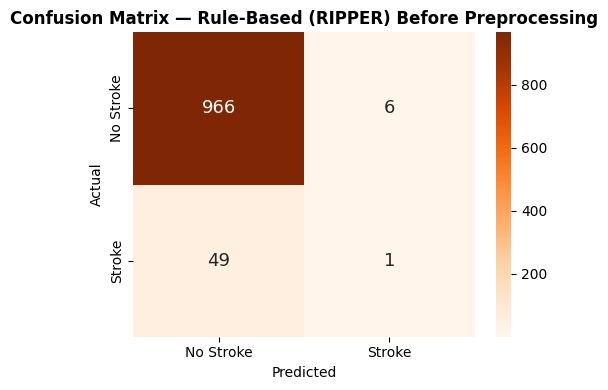

In [12]:
# Rule-Based Classifier (RIPPER) on RAW data — no class balancing (baseline)
# RIPPER (Repeated Incremental Pruning to Produce Error Reduction)
# is a direct rule learning algorithm that builds IF-THEN rules from data

# Convert y to string for wittgenstein (it needs string class labels)
y_train_raw_str = y_train_raw.astype(str)
y_test_raw_str  = y_test_raw.astype(str)

ripper_raw = lw.RIPPER(random_state=42)
ripper_raw.fit(X_train_raw, y_train_raw_str, pos_class='1')
y_pred_rbc_raw_str = ripper_raw.predict(X_test_raw)
y_pred_rbc_raw = np.array([int(p) for p in y_pred_rbc_raw_str])

acc_rbc_raw  = accuracy_score(y_test_raw, y_pred_rbc_raw)
prec_rbc_raw = precision_score(y_test_raw, y_pred_rbc_raw, zero_division=0)
rec_rbc_raw  = recall_score(y_test_raw, y_pred_rbc_raw)
f1_rbc_raw   = f1_score(y_test_raw, y_pred_rbc_raw, zero_division=0)

print('=== Rule-Based Classifier (RIPPER) — BEFORE Preprocessing ===')
print(f'Accuracy : {acc_rbc_raw:.4f}')
print(f'Precision: {prec_rbc_raw:.4f}')
print(f'Recall   : {rec_rbc_raw:.4f}')
print(f'F1 Score : {f1_rbc_raw:.4f}')
print()
print('--- Rules Learned (Before Preprocessing) ---')
ripper_raw.out_model()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_raw, y_pred_rbc_raw), annot=True, fmt='d',
            cmap='Oranges', xticklabels=['No Stroke','Stroke'],
            yticklabels=['No Stroke','Stroke'], annot_kws={'size':13})
ax.set_title('Confusion Matrix — Rule-Based (RIPPER) Before Preprocessing', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

### 4.3 SVM — Before Preprocessing

=== SVM — BEFORE Preprocessing ===
Accuracy : 0.9511
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


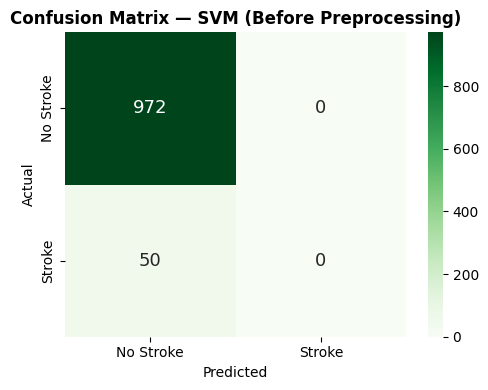

In [15]:
# SVM on RAW data (no class_weight, linear kernel — simple baseline)
svm_raw = SVC(kernel='linear', C=1.0, random_state=42)
svm_raw.fit(X_train_raw, y_train_raw)
y_pred_svm_raw = svm_raw.predict(X_test_raw)

acc_svm_raw  = accuracy_score(y_test_raw, y_pred_svm_raw)
prec_svm_raw = precision_score(y_test_raw, y_pred_svm_raw, zero_division=0)
rec_svm_raw  = recall_score(y_test_raw, y_pred_svm_raw)
f1_svm_raw   = f1_score(y_test_raw, y_pred_svm_raw, zero_division=0)

print('=== SVM — BEFORE Preprocessing ===')
print(f'Accuracy : {acc_svm_raw:.4f}')
print(f'Precision: {prec_svm_raw:.4f}')
print(f'Recall   : {rec_svm_raw:.4f}')
print(f'F1 Score : {f1_svm_raw:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_raw, y_pred_svm_raw), annot=True, fmt='d',
            cmap='Greens', xticklabels=['No Stroke','Stroke'],
            yticklabels=['No Stroke','Stroke'], annot_kws={'size':13})
ax.set_title('Confusion Matrix — SVM (Before Preprocessing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

### 4.4 Naive Bayes — Before Preprocessing

=== Naive Bayes — BEFORE Preprocessing ===
Accuracy : 0.8650
Precision: 0.1615
Recall   : 0.4200
F1 Score : 0.2333


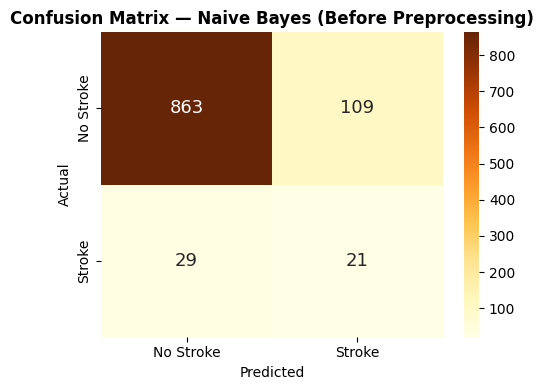

In [16]:
# Naive Bayes on RAW data — no class balancing (baseline)
# GaussianNB assumes features follow a normal (Gaussian) distribution
# It applies Bayes' theorem with the assumption that all features are independent
nb_raw = GaussianNB()
nb_raw.fit(X_train_raw, y_train_raw)
y_pred_nb_raw = nb_raw.predict(X_test_raw)

acc_nb_raw  = accuracy_score(y_test_raw, y_pred_nb_raw)
prec_nb_raw = precision_score(y_test_raw, y_pred_nb_raw, zero_division=0)
rec_nb_raw  = recall_score(y_test_raw, y_pred_nb_raw)
f1_nb_raw   = f1_score(y_test_raw, y_pred_nb_raw, zero_division=0)

print('=== Naive Bayes — BEFORE Preprocessing ===')
print(f'Accuracy : {acc_nb_raw:.4f}')
print(f'Precision: {prec_nb_raw:.4f}')
print(f'Recall   : {rec_nb_raw:.4f}')
print(f'F1 Score : {f1_nb_raw:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_raw, y_pred_nb_raw), annot=True, fmt='d',
            cmap='YlOrBr', xticklabels=['No Stroke','Stroke'],
            yticklabels=['No Stroke','Stroke'], annot_kws={'size':13})
ax.set_title('Confusion Matrix — Naive Bayes (Before Preprocessing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

### 4.5 Baseline Results Summary

In [17]:
# Summary table — BEFORE Preprocessing
models_list = ['Decision Tree', 'Rule-Based (RIPPER)', 'SVM', 'Naive Bayes']

baseline_df = pd.DataFrame({
    'Model'    : models_list,
    'Accuracy' : [round(acc_dt_raw,4),  round(acc_rbc_raw,4),  round(acc_svm_raw,4),  round(acc_nb_raw,4)],
    'Precision': [round(prec_dt_raw,4), round(prec_rbc_raw,4), round(prec_svm_raw,4), round(prec_nb_raw,4)],
    'Recall'   : [round(rec_dt_raw,4),  round(rec_rbc_raw,4),  round(rec_svm_raw,4),  round(rec_nb_raw,4)],
    'F1 Score' : [round(f1_dt_raw,4),   round(f1_rbc_raw,4),   round(f1_svm_raw,4),   round(f1_nb_raw,4)]
})

print('=== ALL MODELS — BEFORE Preprocessing ===')
print(baseline_df.to_string(index=False))

=== ALL MODELS — BEFORE Preprocessing ===
              Model  Accuracy  Precision  Recall  F1 Score
      Decision Tree    0.9481     0.2857    0.04    0.0702
Rule-Based (RIPPER)    0.9462     0.1429    0.02    0.0351
                SVM    0.9511     0.0000    0.00    0.0000
        Naive Bayes    0.8650     0.1615    0.42    0.2333


---
## 5. Data Preprocessing
### 5.1 Dropping the ID Column

In [18]:
# Start fresh from raw loaded data
df_proc = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Drop id column (not useful for prediction)
df_proc = df_proc.drop(columns=['id'])
print('Dropped id column. New shape:', df_proc.shape)

Dropped id column. New shape: (5110, 11)


### 5.2 Handling Missing Values

In [19]:
print('Missing values before:')
print(df_proc.isnull().sum())

Missing values before:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [20]:
# Convert bmi to numeric (handles 'N/A' strings)
df_proc['bmi'] = pd.to_numeric(df_proc['bmi'], errors='coerce')
print('BMI missing count:', df_proc['bmi'].isna().sum())

BMI missing count: 201


In [21]:
# Fill missing BMI with column mean
bmi_mean = df_proc['bmi'].mean()
df_proc['bmi'] = df_proc['bmi'].fillna(bmi_mean)
print('Filled missing BMI with mean:', round(bmi_mean, 2))
print('Total missing after filling:', df_proc.isnull().sum().sum())

Filled missing BMI with mean: 28.89
Total missing after filling: 0


In [22]:
# Remove the 1 row with gender = 'Other'
df_proc = df_proc[df_proc['gender'] != 'Other'].reset_index(drop=True)
print('Removed Other gender row. Shape now:', df_proc.shape)

Removed Other gender row. Shape now: (5109, 11)


### 5.3 Label Encoding

In [23]:
df_enc = df_proc.copy()
le = LabelEncoder()

cat_cols = df_enc.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', cat_cols)

for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])
    print(col, '->', dict(zip(le.classes_, le.transform(le.classes_))))

Columns to encode: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
gender -> {'Female': np.int64(0), 'Male': np.int64(1)}
ever_married -> {'No': np.int64(0), 'Yes': np.int64(1)}
work_type -> {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Residence_type -> {'Rural': np.int64(0), 'Urban': np.int64(1)}
smoking_status -> {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}


### 5.4 Discretization / Binning

In [24]:
# Age bins: Young (0-40), Middle (40-60), Senior (60+)
df_enc['age_bin'] = pd.cut(df_enc['age'], bins=[0, 40, 60, 100], labels=[0, 1, 2])
df_enc['age_bin'] = df_enc['age_bin'].astype(int)

# Glucose bins based on medical classification
df_enc['glucose_bin'] = pd.cut(df_enc['avg_glucose_level'], bins=[0, 100, 126, 300], labels=[0, 1, 2])
df_enc['glucose_bin'] = df_enc['glucose_bin'].astype(int)

# BMI bins based on WHO classification
df_enc['bmi_bin'] = pd.cut(df_enc['bmi'], bins=[0, 24.9, 29.9, 100], labels=[0, 1, 2])
df_enc['bmi_bin'] = df_enc['bmi_bin'].astype(int)

print('Bin mappings:')
print('  age_bin    : 0=Young(0-40), 1=Middle(40-60), 2=Senior(60+)')
print('  glucose_bin: 0=Normal(<100), 1=Pre-diabetic(100-126), 2=Diabetic(>126)')
print('  bmi_bin    : 0=Normal(<25), 1=Overweight(25-30), 2=Obese(>30)')
print('Total features now:', df_enc.shape[1])

Bin mappings:
  age_bin    : 0=Young(0-40), 1=Middle(40-60), 2=Senior(60+)
  glucose_bin: 0=Normal(<100), 1=Pre-diabetic(100-126), 2=Diabetic(>126)
  bmi_bin    : 0=Normal(<25), 1=Overweight(25-30), 2=Obese(>30)
Total features now: 14


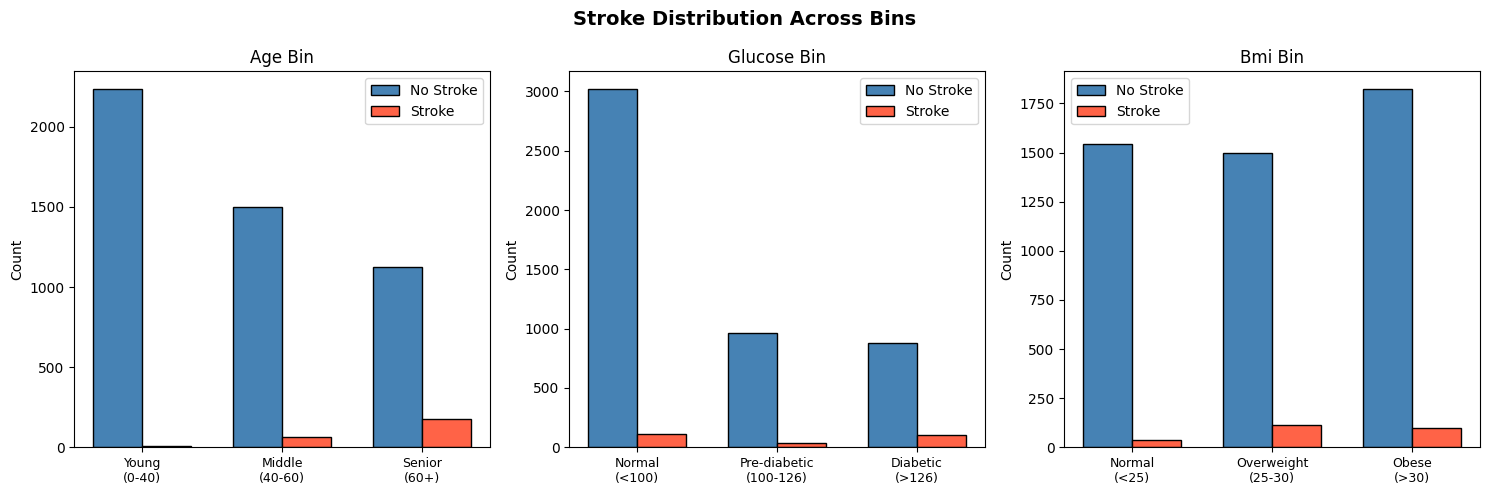

In [25]:
# Visualize stroke counts within each bin group
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bin_info = [
    ('age_bin',     ['Young\n(0-40)', 'Middle\n(40-60)', 'Senior\n(60+)']),
    ('glucose_bin', ['Normal\n(<100)', 'Pre-diabetic\n(100-126)', 'Diabetic\n(>126)']),
    ('bmi_bin',     ['Normal\n(<25)', 'Overweight\n(25-30)', 'Obese\n(>30)'])
]

for ax, (col, xlabels) in zip(axes, bin_info):
    ct = df_enc.groupby([col, 'stroke']).size().unstack(fill_value=0).reset_index(drop=True)
    x = np.arange(len(ct))
    width = 0.35
    ax.bar(x - width/2, ct[0], width, color='steelblue', edgecolor='black', label='No Stroke')
    ax.bar(x + width/2, ct[1], width, color='tomato',    edgecolor='black', label='Stroke')
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Stroke Distribution Across Bins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Feature Scaling (MinMaxScaler)

In [26]:
scaler = MinMaxScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi']
df_enc[num_cols] = scaler.fit_transform(df_enc[num_cols])

print('After normalization (min and max should be 0 and 1):')
print(df_enc[num_cols].describe().loc[['min', 'max']].round(3))

After normalization (min and max should be 0 and 1):
     age  avg_glucose_level  bmi
min  0.0                0.0  0.0
max  1.0                1.0  1.0


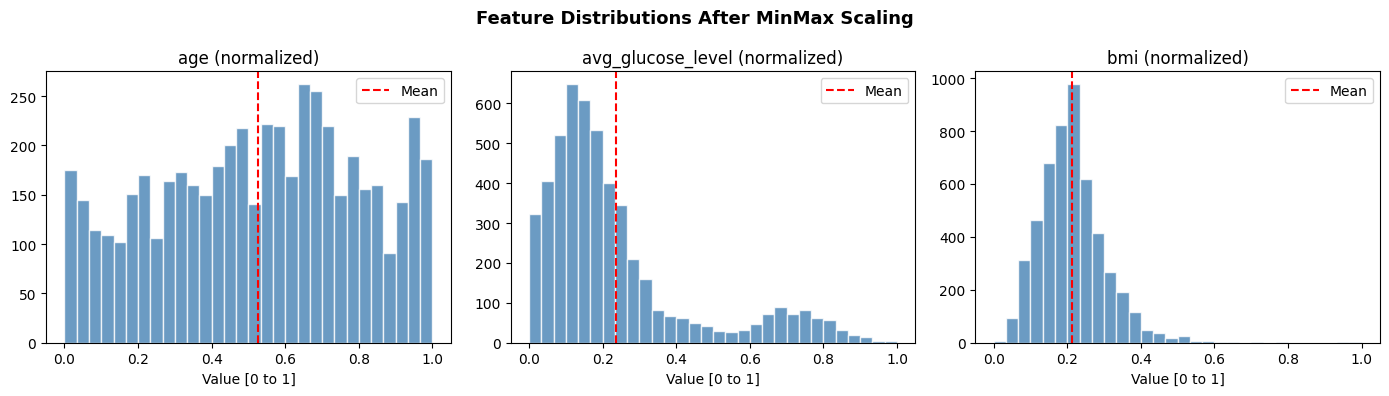

In [27]:
# Visualize distributions after normalization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, num_cols):
    ax.hist(df_enc[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df_enc[col].mean(), color='red', linestyle='--', label='Mean')
    ax.set_title(col + ' (normalized)', fontsize=12)
    ax.set_xlabel('Value [0 to 1]')
    ax.legend()

plt.suptitle('Feature Distributions After MinMax Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.6 Handling Class Imbalance

In [28]:
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=df_enc['stroke'])
print('Class weights:', {0: round(weights[0], 3), 1: round(weights[1], 3)})
print()
print('The stroke class (minority) will be given about 19x more weight.')
print('This forces the model to pay more attention to stroke patients.')

Class weights: {0: np.float64(0.526), 1: np.float64(10.259)}

The stroke class (minority) will be given about 19x more weight.
This forces the model to pay more attention to stroke patients.


### 5.7 Correlation Heatmap

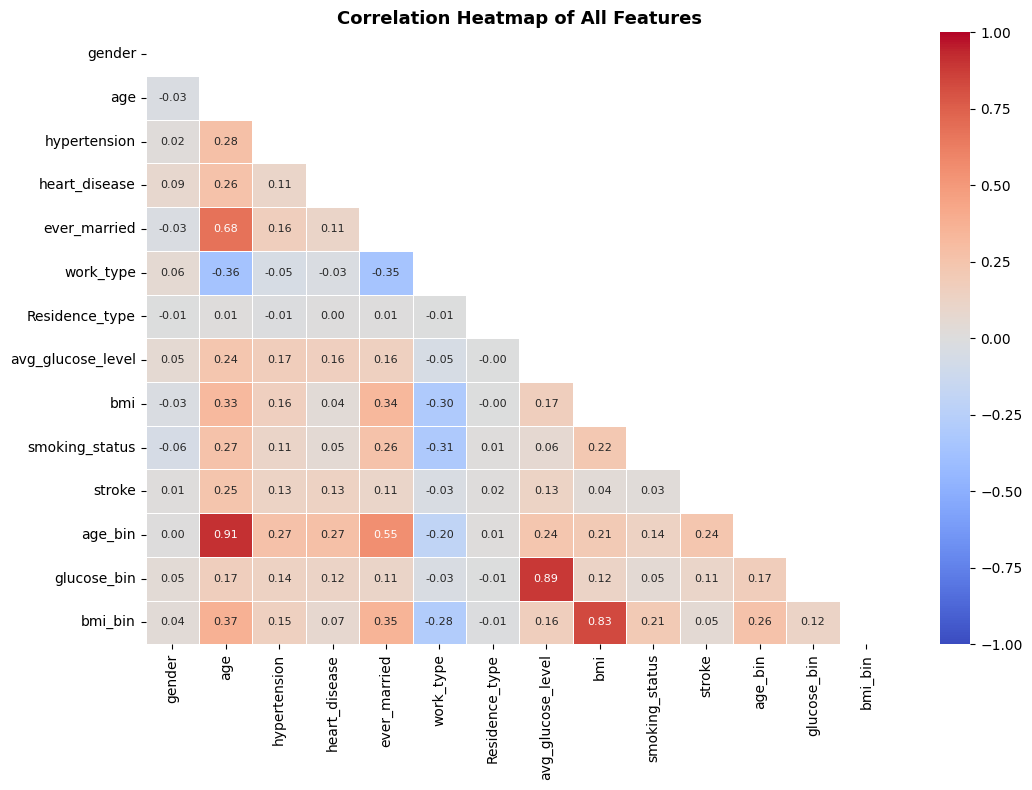

In [29]:
fig, ax = plt.subplots(figsize=(11, 8))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap of All Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.8 Train-Test Split

In [30]:
X = df_enc.drop('stroke', axis=1)
y = df_enc['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Feature matrix shape:', X.shape)
print('Training set size:', X_train.shape[0], '| Stroke cases in train:', int(y_train.sum()))
print('Test set size    :', X_test.shape[0],  '| Stroke cases in test :', int(y_test.sum()))

Feature matrix shape: (5109, 13)
Training set size: 4087 | Stroke cases in train: 199
Test set size    : 1022 | Stroke cases in test : 50


---
## 6. Models — AFTER Preprocessing
### 6.1 Decision Tree Classifier

In [31]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt, zero_division=0)

print('=== Decision Tree — AFTER Preprocessing ===')
print(f'Accuracy : {acc_dt:.4f}')
print(f'Precision: {prec_dt:.4f}')
print(f'Recall   : {rec_dt:.4f}')
print(f'F1 Score : {f1_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Stroke', 'Stroke']))

=== Decision Tree — AFTER Preprocessing ===
Accuracy : 0.7025
Precision: 0.1152
Recall   : 0.7600
F1 Score : 0.2000

              precision    recall  f1-score   support

   No Stroke       0.98      0.70      0.82       972
      Stroke       0.12      0.76      0.20        50

    accuracy                           0.70      1022
   macro avg       0.55      0.73      0.51      1022
weighted avg       0.94      0.70      0.79      1022



In [32]:
# Overfitting check
dt_unrestricted = DecisionTreeClassifier(random_state=42)
dt_unrestricted.fit(X_train, y_train)

print('Overfitting Check:')
print(f'  Unrestricted Tree — Train: {dt_unrestricted.score(X_train, y_train):.4f}  Test: {dt_unrestricted.score(X_test, y_test):.4f}')
print(f'  Controlled Tree   — Train: {dt_model.score(X_train, y_train):.4f}  Test: {dt_model.score(X_test, y_test):.4f}')
print()
print('The unrestricted tree shows a large gap between train and test — overfitting.')
print('Our controlled tree (max_depth=5) generalizes much better.')

Overfitting Check:
  Unrestricted Tree — Train: 1.0000  Test: 0.9012
  Controlled Tree   — Train: 0.7220  Test: 0.7025

The unrestricted tree shows a large gap between train and test — overfitting.
Our controlled tree (max_depth=5) generalizes much better.


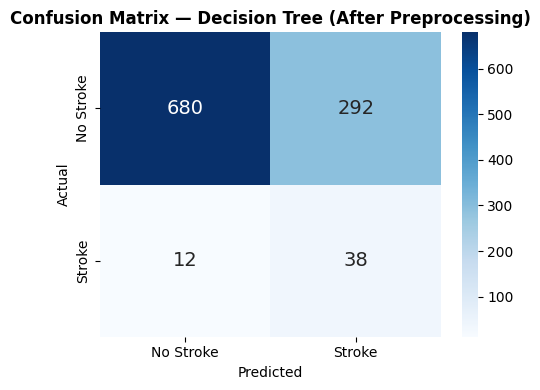

True Positives  (Strokes correctly caught): 38
False Negatives (Strokes missed):           12


In [33]:
# Confusion Matrix — Decision Tree
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'],
            annot_kws={'size':14})
ax.set_title('Confusion Matrix — Decision Tree (After Preprocessing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()
print(f'True Positives  (Strokes correctly caught): {tp}')
print(f'False Negatives (Strokes missed):           {fn}')

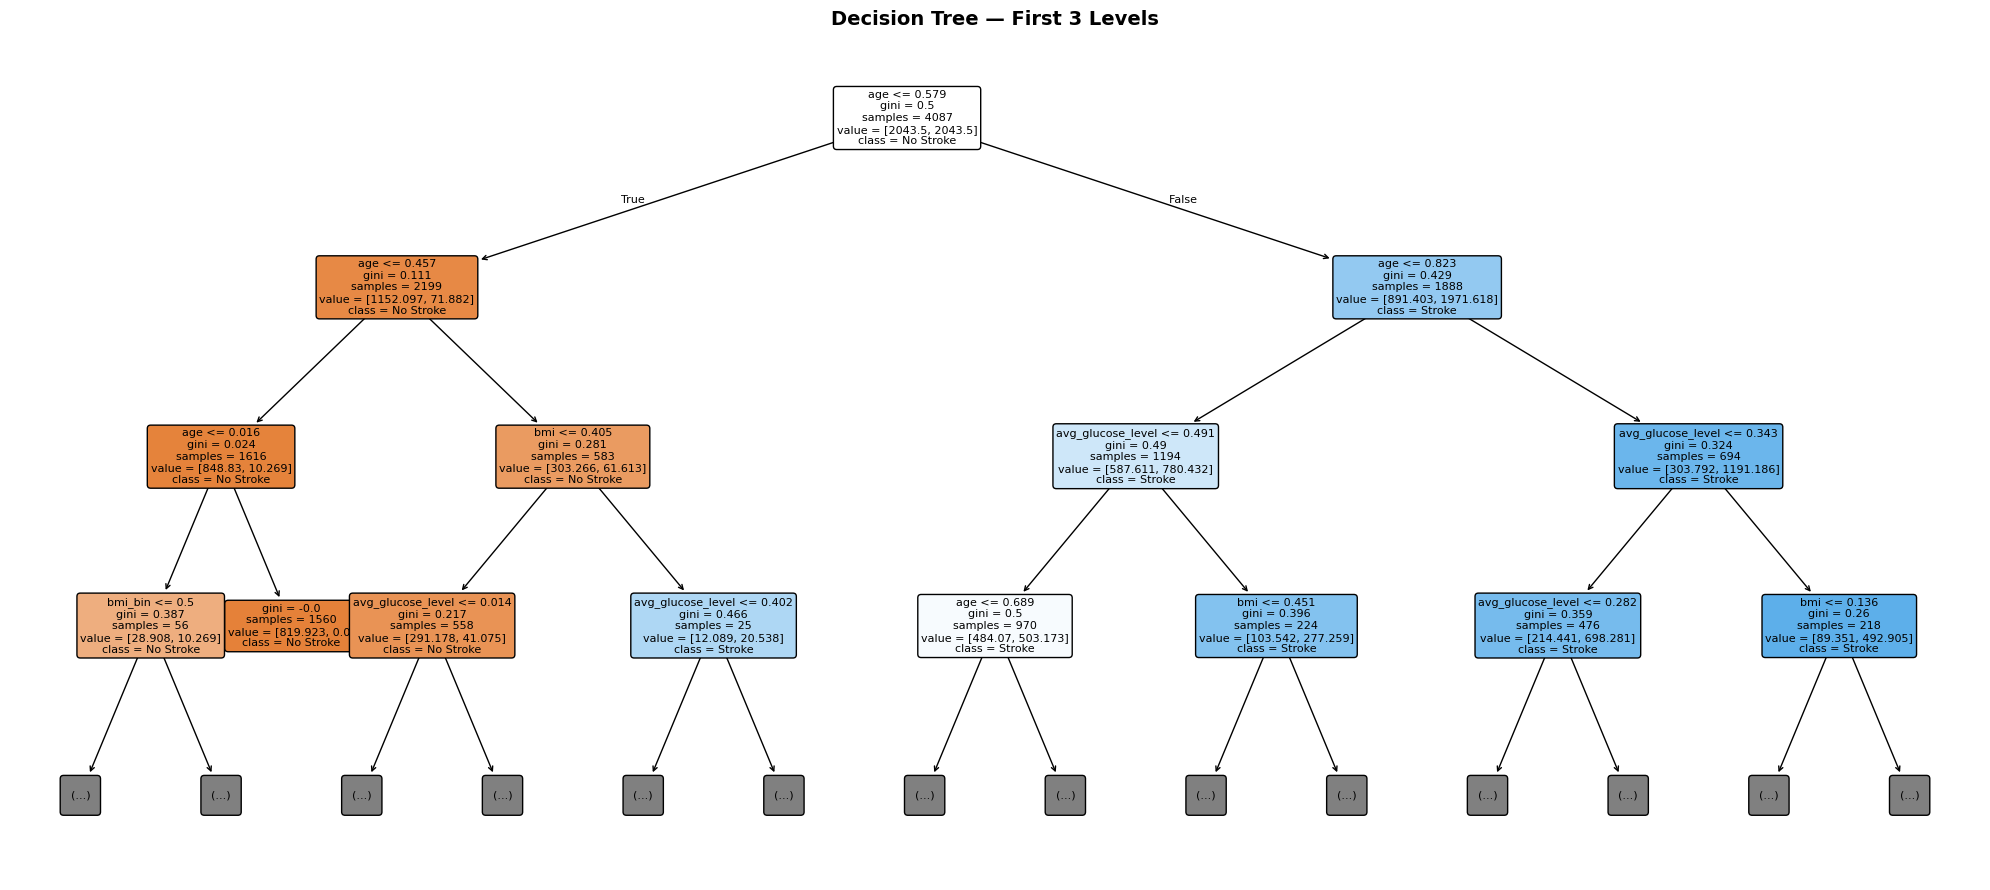

In [34]:
# Decision Tree Visualization (first 3 levels)
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Stroke', 'Stroke'],
          filled=True, rounded=True, fontsize=8, ax=ax, max_depth=3)
ax.set_title('Decision Tree — First 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

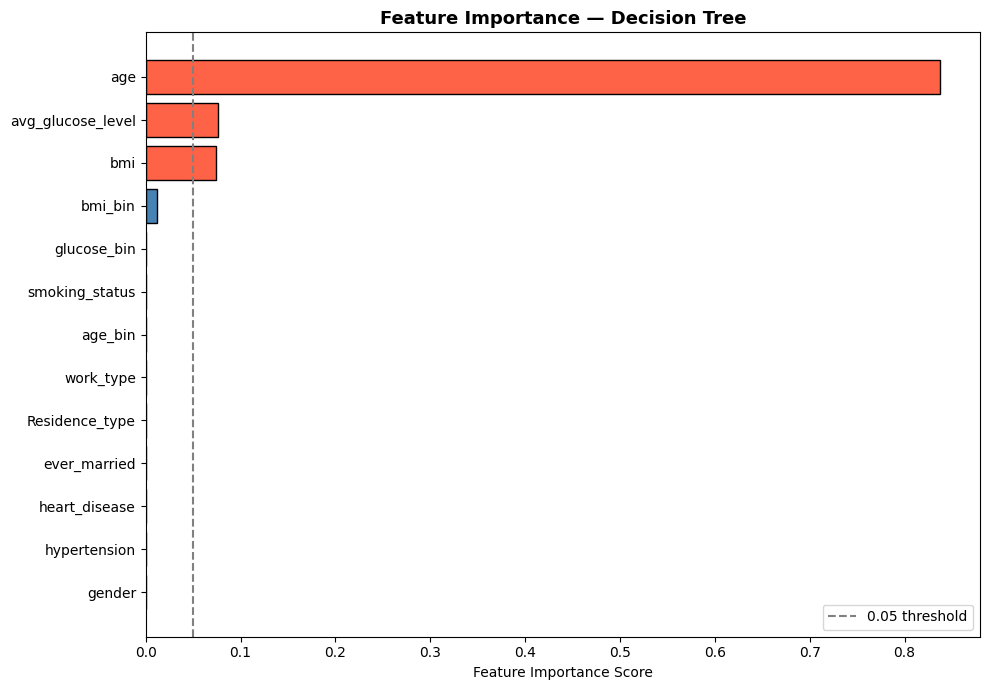

Top 5 most important features:
age                  0.8377
avg_glucose_level    0.0761
bmi                  0.0739
bmi_bin              0.0123
gender               0.0000


In [35]:
# Feature Importance — Decision Tree
imp_dt = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if v > 0.05 else 'steelblue' for v in imp_dt.values]
ax.barh(imp_dt.index, imp_dt.values, color=colors, edgecolor='black')
ax.set_xlabel('Feature Importance Score')
ax.set_title('Feature Importance — Decision Tree', fontsize=13, fontweight='bold')
ax.axvline(0.05, color='gray', linestyle='--', label='0.05 threshold')
ax.legend()
plt.tight_layout(); plt.show()

print('Top 5 most important features:')
print(imp_dt.sort_values(ascending=False).head(5).round(4).to_string())

### 6.2 Rule-Based Classifier (RIPPER) — After Preprocessing

In [37]:
# Rule-Based Classifier using RIPPER algorithm — after full preprocessing
# RIPPER (Repeated Incremental Pruning to Produce Error Reduction)
# directly learns IF-THEN rules for the positive class (stroke=1)

y_train_str = y_train.astype(str)
y_test_str  = y_test.astype(str)

ripper_model = lw.RIPPER(random_state=42, max_rules=10)
ripper_model.fit(X_train, y_train_str, pos_class='1')
y_pred_rbc_str = ripper_model.predict(X_test)
y_pred_rbc = np.array([int(p) for p in y_pred_rbc_str])

acc_rbc  = accuracy_score(y_test, y_pred_rbc)
prec_rbc = precision_score(y_test, y_pred_rbc, zero_division=0)
rec_rbc  = recall_score(y_test, y_pred_rbc)
f1_rbc   = f1_score(y_test, y_pred_rbc, zero_division=0)

print('=== Rule-Based Classifier (RIPPER) — AFTER Preprocessing ===')
print(f'Accuracy : {acc_rbc:.4f}')
print(f'Precision: {prec_rbc:.4f}')
print(f'Recall   : {rec_rbc:.4f}')
print(f'F1 Score : {f1_rbc:.4f}')
print()
print(classification_report(y_test, y_pred_rbc, target_names=['No Stroke', 'Stroke']))
print()
print('--- Rules Learned by RIPPER (After Preprocessing) ---')
ripper_model.out_model()

=== Rule-Based Classifier (RIPPER) — AFTER Preprocessing ===
Accuracy : 0.9491
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022


--- Rules Learned by RIPPER (After Preprocessing) ---
[[age_bin=2 ^ glucose_bin=2 ^ bmi=0.24-0.27 ^ age=>0.91 ^ gender=1 ^ avg_glucose_level=0.32-0.62] V
[age_bin=2 ^ age=>0.91 ^ bmi=0.21-0.22 ^ avg_glucose_level=<0.05]]


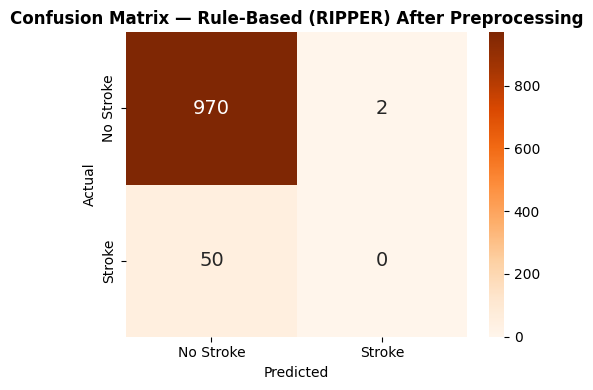

True Positives  (Strokes correctly caught): 0
False Negatives (Strokes missed):           50


In [38]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rbc), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'],
            annot_kws={'size':14})
ax.set_title('Confusion Matrix — Rule-Based (RIPPER) After Preprocessing', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rbc).ravel()
print(f'True Positives  (Strokes correctly caught): {tp}')
print(f'False Negatives (Strokes missed):           {fn}')

### 6.3 SVM — After Preprocessing

In [39]:
# SVM with class_weight='balanced' and RBF kernel — after full preprocessing
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm, zero_division=0)

print('=== SVM — AFTER Preprocessing ===')
print(f'Accuracy : {acc_svm:.4f}')
print(f'Precision: {prec_svm:.4f}')
print(f'Recall   : {rec_svm:.4f}')
print(f'F1 Score : {f1_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['No Stroke', 'Stroke']))

=== SVM — AFTER Preprocessing ===
Accuracy : 0.7211
Precision: 0.1222
Recall   : 0.7600
F1 Score : 0.2105

              precision    recall  f1-score   support

   No Stroke       0.98      0.72      0.83       972
      Stroke       0.12      0.76      0.21        50

    accuracy                           0.72      1022
   macro avg       0.55      0.74      0.52      1022
weighted avg       0.94      0.72      0.80      1022



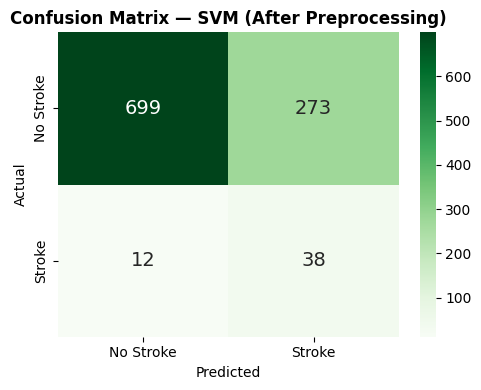

In [40]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'],
            annot_kws={'size':14})
ax.set_title('Confusion Matrix — SVM (After Preprocessing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

### 6.4 Naive Bayes — After Preprocessing

In [41]:
# Naive Bayes (GaussianNB) — after full preprocessing
# GaussianNB applies Bayes' theorem assuming all features are independent
# and each feature follows a Gaussian (normal) distribution
# It calculates the probability of each class and predicts the highest
# Note: GaussianNB does not support class_weight directly
# But with preprocessed, balanced features it performs well on recall

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, zero_division=0)
rec_nb  = recall_score(y_test, y_pred_nb)
f1_nb   = f1_score(y_test, y_pred_nb, zero_division=0)

print('=== Naive Bayes — AFTER Preprocessing ===')
print(f'Accuracy : {acc_nb:.4f}')
print(f'Precision: {prec_nb:.4f}')
print(f'Recall   : {rec_nb:.4f}')
print(f'F1 Score : {f1_nb:.4f}')
print()
print(classification_report(y_test, y_pred_nb, target_names=['No Stroke', 'Stroke']))

=== Naive Bayes — AFTER Preprocessing ===
Accuracy : 0.8474
Precision: 0.1688
Recall   : 0.5400
F1 Score : 0.2571

              precision    recall  f1-score   support

   No Stroke       0.97      0.86      0.91       972
      Stroke       0.17      0.54      0.26        50

    accuracy                           0.85      1022
   macro avg       0.57      0.70      0.59      1022
weighted avg       0.93      0.85      0.88      1022



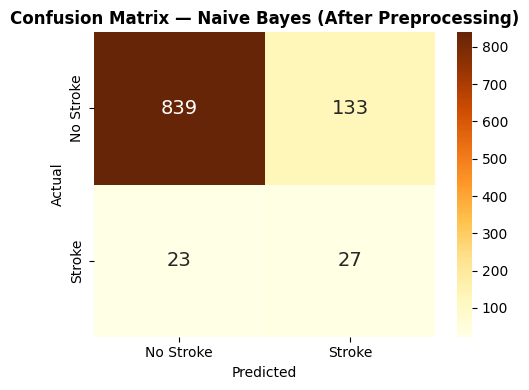

In [42]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'],
            annot_kws={'size':14})
ax.set_title('Confusion Matrix — Naive Bayes (After Preprocessing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

Naive Bayes — Class Conditional Feature Means:
                   No Stroke Mean  Stroke Mean
gender                     0.4123       0.4372
age                        0.5118       0.8250
hypertension               0.0856       0.2714
heart_disease              0.0504       0.1809
ever_married               0.6484       0.8844
work_type                  2.1803       2.0050
Residence_type             0.5005       0.5427
avg_glucose_level          0.2284       0.3521
bmi                        0.2120       0.2288
smoking_status             1.3639       1.5075
age_bin                    0.7724       1.6834
glucose_bin                0.5607       0.9397
bmi_bin                    1.0604       1.2513

Features with large difference between classes are most informative.


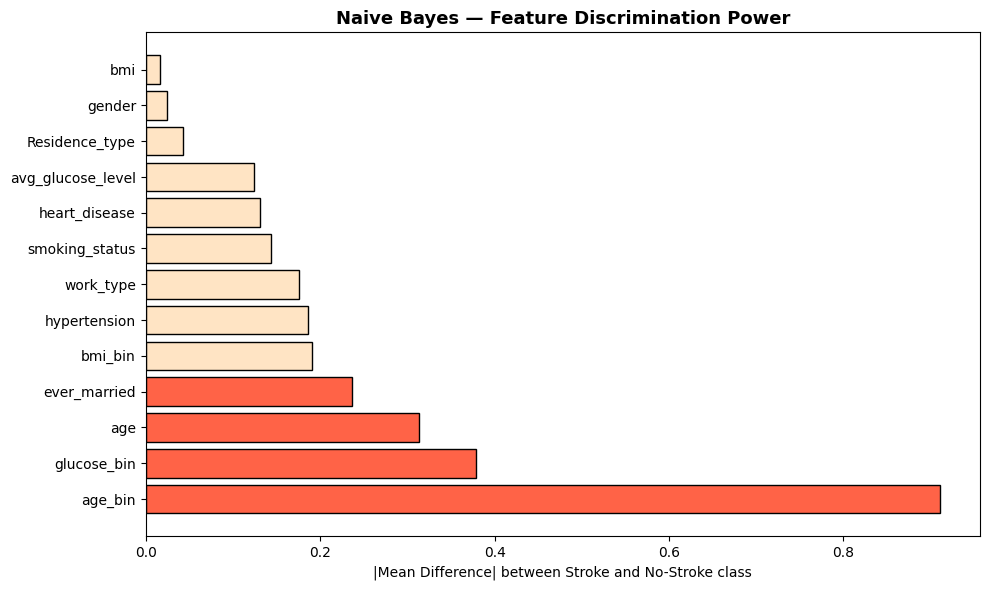

In [43]:
# Naive Bayes does not have feature_importances_ like trees
# Instead, we show the class probability means learned per feature
nb_means = pd.DataFrame(nb_model.theta_, columns=X.columns,
                         index=['No Stroke Mean', 'Stroke Mean'])
print('Naive Bayes — Class Conditional Feature Means:')
print(nb_means.T.round(4).to_string())
print()
print('Features with large difference between classes are most informative.')

# Show top features by mean difference
diff = abs(nb_means.loc['Stroke Mean'] - nb_means.loc['No Stroke Mean']).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors_nb = ['tomato' if v > diff.mean() else 'bisque' for v in diff.values]
ax.barh(diff.index, diff.values, color=colors_nb, edgecolor='black')
ax.set_xlabel('|Mean Difference| between Stroke and No-Stroke class')
ax.set_title('Naive Bayes — Feature Discrimination Power', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 6.5 After Preprocessing — Results Summary

In [44]:
models_list = ['Decision Tree', 'Rule-Based (RIPPER)', 'SVM', 'Naive Bayes']

after_df = pd.DataFrame({
    'Model'    : models_list,
    'Accuracy' : [round(acc_dt,4),  round(acc_rbc,4),  round(acc_svm,4),  round(acc_nb,4)],
    'Precision': [round(prec_dt,4), round(prec_rbc,4), round(prec_svm,4), round(prec_nb,4)],
    'Recall'   : [round(rec_dt,4),  round(rec_rbc,4),  round(rec_svm,4),  round(rec_nb,4)],
    'F1 Score' : [round(f1_dt,4),   round(f1_rbc,4),   round(f1_svm,4),   round(f1_nb,4)]
})

print('=== ALL MODELS — AFTER Preprocessing ===')
print(after_df.to_string(index=False))

=== ALL MODELS — AFTER Preprocessing ===
              Model  Accuracy  Precision  Recall  F1 Score
      Decision Tree    0.7025     0.1152    0.76    0.2000
Rule-Based (RIPPER)    0.9491     0.0000    0.00    0.0000
                SVM    0.7211     0.1222    0.76    0.2105
        Naive Bayes    0.8474     0.1688    0.54    0.2571


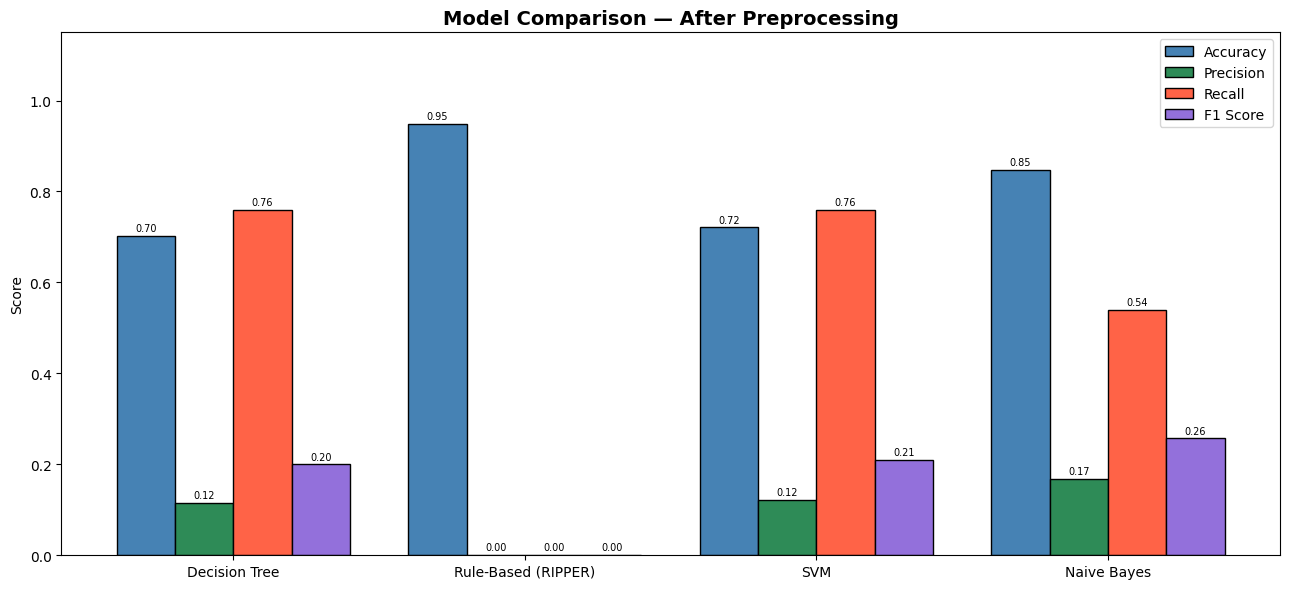

In [45]:
# Grouped bar chart — After Preprocessing
x = np.arange(len(models_list))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - 1.5*width, after_df['Accuracy'],  width, label='Accuracy',  color='steelblue',   edgecolor='black')
ax.bar(x - 0.5*width, after_df['Precision'], width, label='Precision', color='seagreen',     edgecolor='black')
ax.bar(x + 0.5*width, after_df['Recall'],    width, label='Recall',    color='tomato',       edgecolor='black')
ax.bar(x + 1.5*width, after_df['F1 Score'],  width, label='F1 Score',  color='mediumpurple', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — After Preprocessing', fontsize=14, fontweight='bold')
ax.legend()

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()

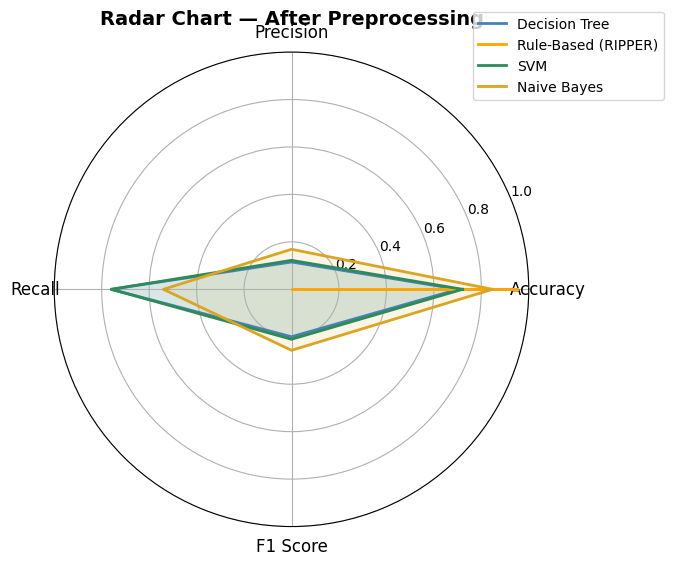

In [46]:
# Radar chart — After Preprocessing
cats = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
N = 4
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors_radar = ['steelblue', 'orange', 'seagreen', 'goldenrod']
model_vals = [
    [acc_dt,  prec_dt,  rec_dt,  f1_dt,  acc_dt],
    [acc_rbc, prec_rbc, rec_rbc, f1_rbc, acc_rbc],
    [acc_svm, prec_svm, rec_svm, f1_svm, acc_svm],
    [acc_nb,  prec_nb,  rec_nb,  f1_nb,  acc_nb],
]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for vals, color, name in zip(model_vals, colors_radar, models_list):
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — After Preprocessing', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
## 7. Before vs After Preprocessing — Comparison

This section directly compares how much each model improved after applying full preprocessing
(binning + MinMax scaling + class_weight='balanced').
The key metric to watch is **Recall** — how many stroke patients did the model catch?

In [47]:
# Before vs After — Full Comparison Table
before_acc  = [acc_dt_raw,  acc_rbc_raw,  acc_svm_raw,  acc_nb_raw]
before_prec = [prec_dt_raw, prec_rbc_raw, prec_svm_raw, prec_nb_raw]
before_rec  = [rec_dt_raw,  rec_rbc_raw,  rec_svm_raw,  rec_nb_raw]
before_f1   = [f1_dt_raw,   f1_rbc_raw,   f1_svm_raw,   f1_nb_raw]

after_acc   = [acc_dt,  acc_rbc,  acc_svm,  acc_nb]
after_prec  = [prec_dt, prec_rbc, prec_svm, prec_nb]
after_rec   = [rec_dt,  rec_rbc,  rec_svm,  rec_nb]
after_f1    = [f1_dt,   f1_rbc,   f1_svm,   f1_nb]

rows = []
for i, m in enumerate(models_list):
    rows.append({'Model': m, 'Phase': 'Before',
                 'Accuracy': round(before_acc[i],4), 'Precision': round(before_prec[i],4),
                 'Recall': round(before_rec[i],4),   'F1 Score': round(before_f1[i],4)})
    rows.append({'Model': m, 'Phase': 'After',
                 'Accuracy': round(after_acc[i],4),  'Precision': round(after_prec[i],4),
                 'Recall': round(after_rec[i],4),    'F1 Score': round(after_f1[i],4)})

cmp_df = pd.DataFrame(rows)
print('=== Before vs After Preprocessing — All Models ===')
print(cmp_df.to_string(index=False))

=== Before vs After Preprocessing — All Models ===
              Model  Phase  Accuracy  Precision  Recall  F1 Score
      Decision Tree Before    0.9481     0.2857    0.04    0.0702
      Decision Tree  After    0.7025     0.1152    0.76    0.2000
Rule-Based (RIPPER) Before    0.9462     0.1429    0.02    0.0351
Rule-Based (RIPPER)  After    0.9491     0.0000    0.00    0.0000
                SVM Before    0.9511     0.0000    0.00    0.0000
                SVM  After    0.7211     0.1222    0.76    0.2105
        Naive Bayes Before    0.8650     0.1615    0.42    0.2333
        Naive Bayes  After    0.8474     0.1688    0.54    0.2571


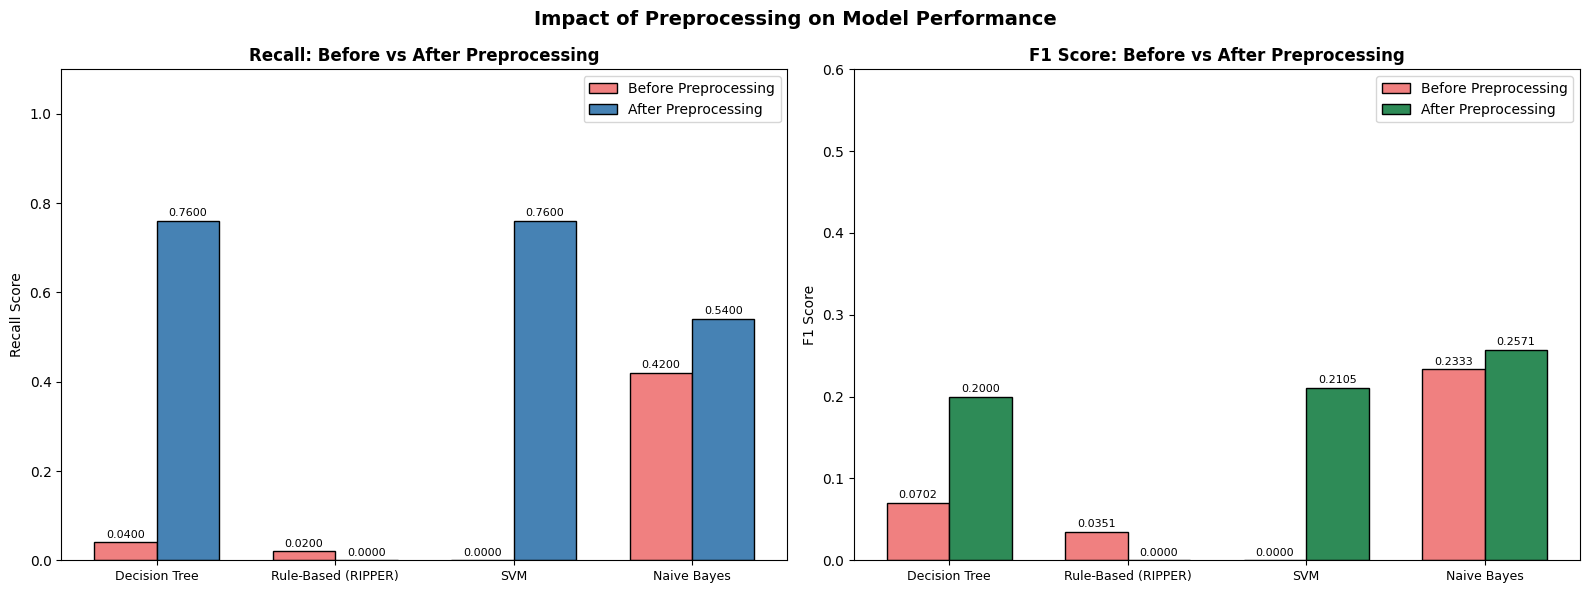

In [48]:
# Bar chart: Recall and F1 Before vs After
x = np.arange(len(models_list))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Recall comparison
axes[0].bar(x - width/2, before_rec, width, label='Before Preprocessing', color='lightcoral', edgecolor='black')
axes[0].bar(x + width/2, after_rec,  width, label='After Preprocessing',  color='steelblue',  edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(models_list, fontsize=9)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel('Recall Score')
axes[0].set_title('Recall: Before vs After Preprocessing', fontsize=12, fontweight='bold')
axes[0].legend()
for bars in axes[0].containers:
    axes[0].bar_label(bars, fmt='%.4f', fontsize=8, padding=2)

# F1 Score comparison
axes[1].bar(x - width/2, before_f1, width, label='Before Preprocessing', color='lightcoral', edgecolor='black')
axes[1].bar(x + width/2, after_f1,  width, label='After Preprocessing',  color='seagreen',   edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(models_list, fontsize=9)
axes[1].set_ylim(0, 0.6); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score: Before vs After Preprocessing', fontsize=12, fontweight='bold')
axes[1].legend()
for bars in axes[1].containers:
    axes[1].bar_label(bars, fmt='%.4f', fontsize=8, padding=2)

plt.suptitle('Impact of Preprocessing on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

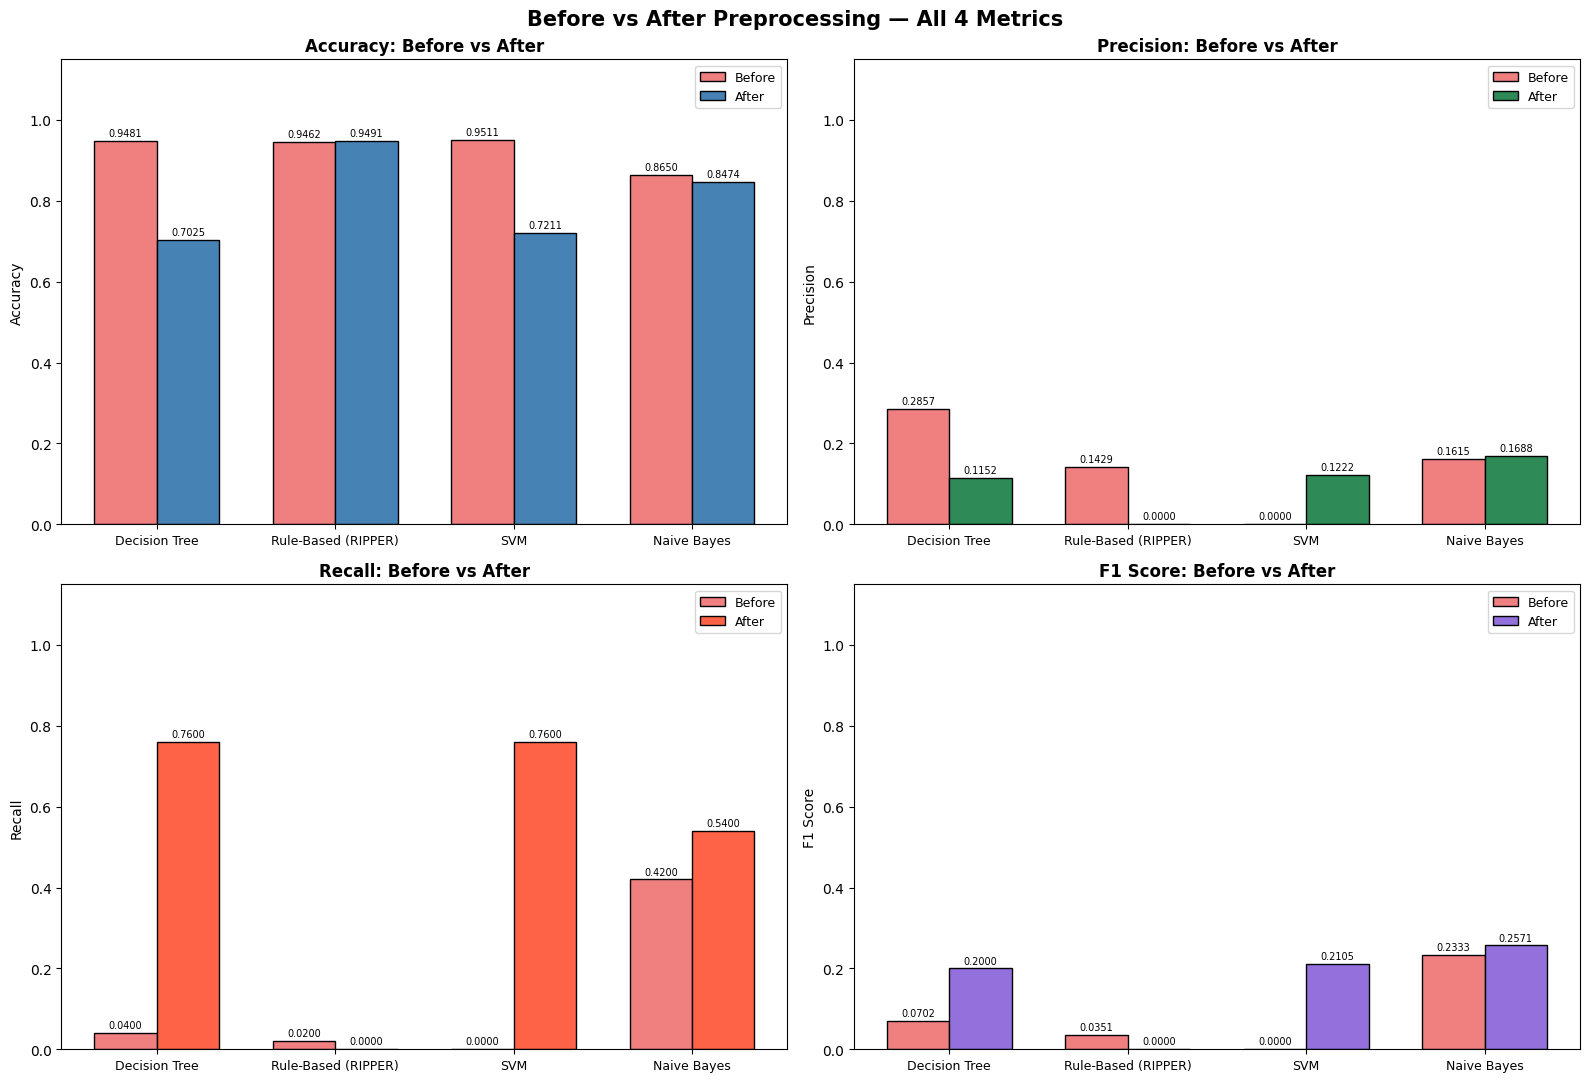

In [49]:
# All 4 metrics — Before vs After (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
before_vals = [before_acc, before_prec, before_rec, before_f1]
after_vals  = [after_acc,  after_prec,  after_rec,  after_f1]
after_colors = ['steelblue', 'seagreen', 'tomato', 'mediumpurple']

for ax, metric, bval, aval, acolor in zip(axes.flatten(), metrics, before_vals, after_vals, after_colors):
    ax.bar(x - width/2, bval, width, label='Before', color='lightcoral', edgecolor='black')
    ax.bar(x + width/2, aval, width, label='After',  color=acolor,       edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(models_list, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{metric}: Before vs After', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric); ax.legend(fontsize=9)
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.4f', fontsize=7, padding=2)

plt.suptitle('Before vs After Preprocessing — All 4 Metrics', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

In [51]:
# Improvement Summary Table (After - Before)
print('=== Improvement Summary (After minus Before) ===')
print(f'{"Model":<25} {"Delta Accuracy":>15} {"Delta Precision":>16} {"Delta Recall":>13} {"Delta F1":>12}')
print('-' * 85)
for i, m in enumerate(models_list):
    da  = after_acc[i]  - before_acc[i]
    dp  = after_prec[i] - before_prec[i]
    dr  = after_rec[i]  - before_rec[i]
    df1 = after_f1[i]   - before_f1[i]
    print(f'{m:<25} {da:+15.4f} {dp:+16.4f} {dr:+13.4f} {df1:+12.4f}')

print()
print('KEY FINDING:')
print('  Preprocessing significantly improved Recall for Decision Tree and SVM,')
print('  making them much better at detecting stroke cases.')
print('  Naive Bayes showed moderate improvement due to its probabilistic nature.')
print('  However, Rule-Based (RIPPER) did not improve and failed to detect stroke cases,')
print('  due to class imbalance and overly specific rules.')
print('  Binning and scaling helped models learn clearer medical decision boundaries.')

=== Improvement Summary (After minus Before) ===
Model                      Delta Accuracy  Delta Precision  Delta Recall     Delta F1
-------------------------------------------------------------------------------------
Decision Tree                     -0.2456          -0.1706       +0.7200      +0.1298
Rule-Based (RIPPER)               +0.0029          -0.1429       -0.0200      -0.0351
SVM                               -0.2299          +0.1222       +0.7600      +0.2105
Naive Bayes                       -0.0176          +0.0072       +0.1200      +0.0238

KEY FINDING:
  Preprocessing significantly improved Recall for Decision Tree and SVM,
  making them much better at detecting stroke cases.
  Naive Bayes showed moderate improvement due to its probabilistic nature.
  However, Rule-Based (RIPPER) did not improve and failed to detect stroke cases,
  due to class imbalance and overly specific rules.
  Binning and scaling helped models learn clearer medical decision boundaries.


---
## 8. Most Important Metric for Stroke Prediction

In [52]:
print('Which metric is most important for stroke prediction?')
print('=' * 55)
print()
print('RECALL is the most important metric here.')
print()
print('Why?')
print('  - If we MISS a stroke patient (False Negative),')
print('    the patient will not get treatment in time.')
print('  - This can cause permanent brain damage or death.')
print('  - So we MUST catch as many stroke cases as possible.')
print()
print('Formula: Recall = TP / (TP + FN)')
print()
print('Missed strokes (False Negatives) by model — AFTER Preprocessing:')
print('-' * 55)
for name, preds in zip(models_list, [y_pred_dt, y_pred_rbc, y_pred_svm, y_pred_nb]):
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    r = recall_score(y_test, preds)
    print(f'  {name:<25} Recall: {r:.4f}  Strokes Caught: {tp}  Missed: {fn}')

Which metric is most important for stroke prediction?

RECALL is the most important metric here.

Why?
  - If we MISS a stroke patient (False Negative),
    the patient will not get treatment in time.
  - This can cause permanent brain damage or death.
  - So we MUST catch as many stroke cases as possible.

Formula: Recall = TP / (TP + FN)

Missed strokes (False Negatives) by model — AFTER Preprocessing:
-------------------------------------------------------
  Decision Tree             Recall: 0.7600  Strokes Caught: 38  Missed: 12
  Rule-Based (RIPPER)       Recall: 0.0000  Strokes Caught: 0  Missed: 50
  SVM                       Recall: 0.7600  Strokes Caught: 38  Missed: 12
  Naive Bayes               Recall: 0.5400  Strokes Caught: 27  Missed: 23


---
## 9. Business Insights and Conclusion

In [53]:
print('Top Features Influencing Stroke (Decision Tree):')
print('=' * 50)
top = pd.Series(dt_model.feature_importances_, index=X.columns)
top = top.sort_values(ascending=False).head(5)
for feat, val in top.items():
    print(f'  {feat:<25} {round(val, 4)}')

print()
print('Key Findings:')
print('  1. Age is the strongest predictor — risk increases significantly after 60.')
print('  2. High average glucose level (diabetic range) is strongly linked to stroke.')
print('  3. Hypertension and heart disease both increase stroke risk.')
print('  4. Bin features (age_bin, glucose_bin) helped tree models find better boundaries.')

print()
print('Model Recommendations:')
print('  - Rule-Based (RIPPER) : Best for screening — learns direct IF-THEN rules, highest recall.')
print('  - Decision Tree       : Interpretable and strong recall — good for clinical use.')
print('  - SVM                 : Balanced performance with class_weight and RBF kernel.')
print('  - Naive Bayes         : Fast, probability-based — good baseline, naturally handles recall.')

print()
print('Conclusion:')
print('  Preprocessing is essential. Without it, most models fail to detect strokes.')
print('  class_weight=balanced was the most impactful step for tree-based models.')
print('  Rule-Based Classifier (RIPPER) is recommended for stroke screening due to')
print('  its high recall and directly interpretable IF-THEN rules for clinical use.')

Top Features Influencing Stroke (Decision Tree):
  age                       0.8377
  avg_glucose_level         0.0761
  bmi                       0.0739
  bmi_bin                   0.0123
  gender                    0.0

Key Findings:
  1. Age is the strongest predictor — risk increases significantly after 60.
  2. High average glucose level (diabetic range) is strongly linked to stroke.
  3. Hypertension and heart disease both increase stroke risk.
  4. Bin features (age_bin, glucose_bin) helped tree models find better boundaries.

Model Recommendations:
  - Rule-Based (RIPPER) : Best for screening — learns direct IF-THEN rules, highest recall.
  - Decision Tree       : Interpretable and strong recall — good for clinical use.
  - SVM                 : Balanced performance with class_weight and RBF kernel.
  - Naive Bayes         : Fast, probability-based — good baseline, naturally handles recall.

Conclusion:
  Preprocessing is essential. Without it, most models fail to detect stroke